# Convolutional Denoising Autoencoder on MNIST

PyTorch example similar to the Tutorial on [autoencoder tutorial](https://keras.io/examples/vision/autoencoder/).

We train a small convolutional autoencoder to (1) reconstruct MNIST digits, then
(2) denoise them after adding Gaussian noise.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3
NOISE_FACTOR = 0.4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

to_tensor = transforms.ToTensor()
train_ds = datasets.MNIST("data", train=True, download=True, transform=to_tensor)
test_ds = datasets.MNIST("data", train=False, download=True, transform=to_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

Device: cuda
Train: 60000, Test: 10000


## 1. Autoencoder Architecture

- Encoder: Conv(32) → MaxPool → Conv(32) → MaxPool → 7×7×32 bottleneck
- Decoder: ConvTranspose(32, stride=2) → ConvTranspose(32, stride=2) → Conv(1, sigmoid)

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
# Quick sanity check on shapes
x = torch.randn(1, 1, 28, 28).to(device)
print(f"Input:  {x.shape}")
print(f"Bottleneck: {model.encoder(x).shape}")
print(f"Output: {model(x).shape}")

Parameters: 28,353
Input:  torch.Size([1, 1, 28, 28])
Bottleneck: torch.Size([1, 32, 7, 7])
Output: torch.Size([1, 1, 28, 28])


## 2. Train on Clean MNIST (Reconstruction)

First teach the autoencoder to reproduce clean digits.
Loss: binary cross-entropy

In [3]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        images = images.to(device)
        recon = model(images)
        loss = criterion(recon, images)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            val_loss += criterion(model(images), images).item()

    print(f"Epoch {epoch+1}: Train Loss={train_loss/len(train_loader):.4f}, Val Loss={val_loss/len(test_loader):.4f}")

torch.save(model.state_dict(), "autoencoder.pth")
print("Saved to autoencoder.pth")

Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.1459, Val Loss=0.0752


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.0731, Val Loss=0.0708


Epoch 3/20:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 18: Train Loss=0.0650, Val Loss=0.0645


Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19: Train Loss=0.0649, Val Loss=0.0645


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20: Train Loss=0.0648, Val Loss=0.0643
Saved to autoencoder.pth


## 3. Reconstruction Results (Clean Inputs)

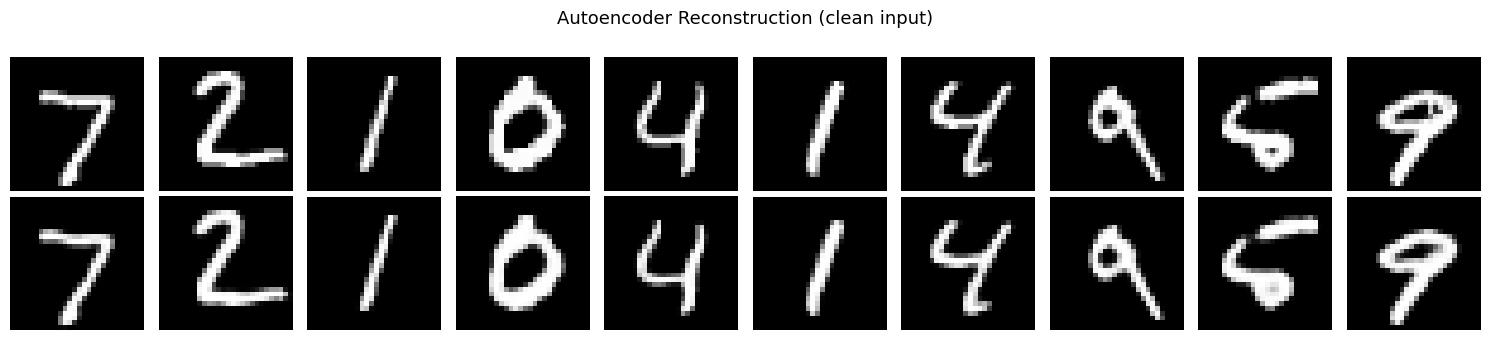

In [4]:
model.eval()
images, _ = next(iter(test_loader))
images = images[:10].to(device)
with torch.no_grad():
    recons = model(images)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for i in range(10):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstruction", fontsize=11)
plt.suptitle("Autoencoder Reconstruction (clean input)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Fine-tune for Denoising

Add Gaussian noise (`factor=0.4`) to inputs, train the autoencoder to output the clean image.

In [5]:
def add_noise(images, factor=NOISE_FACTOR):
    noisy = images + factor * torch.randn_like(images)
    return noisy.clamp(0, 1)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, _ in tqdm(train_loader, desc=f"Denoise Epoch {epoch+1}/{EPOCHS}", leave=False):
        images = images.to(device)
        noisy = add_noise(images)
        recon = model(noisy)
        loss = criterion(recon, images)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy = add_noise(images)
            val_loss += criterion(model(noisy), images).item()

    print(f"Denoise Epoch {epoch+1}: Train Loss={train_loss/len(train_loader):.4f}, Val Loss={val_loss/len(test_loader):.4f}")

torch.save(model.state_dict(), "denoising_ae.pth")
print("Saved to denoising_ae.pth")

Denoise Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Denoise Epoch 1: Train Loss=0.1024, Val Loss=0.0954


Denoise Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Denoise Epoch 2: Train Loss=0.0949, Val Loss=0.0930


Denoise Epoch 3/20:   0%|          | 0/469 [00:00<?, ?it/s]

...

Denoise Epoch 18: Train Loss=0.0878, Val Loss=0.0871


Denoise Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Denoise Epoch 19: Train Loss=0.0876, Val Loss=0.0868


Denoise Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Denoise Epoch 20: Train Loss=0.0875, Val Loss=0.0867
Saved to denoising_ae.pth


## 5. Denoising Results

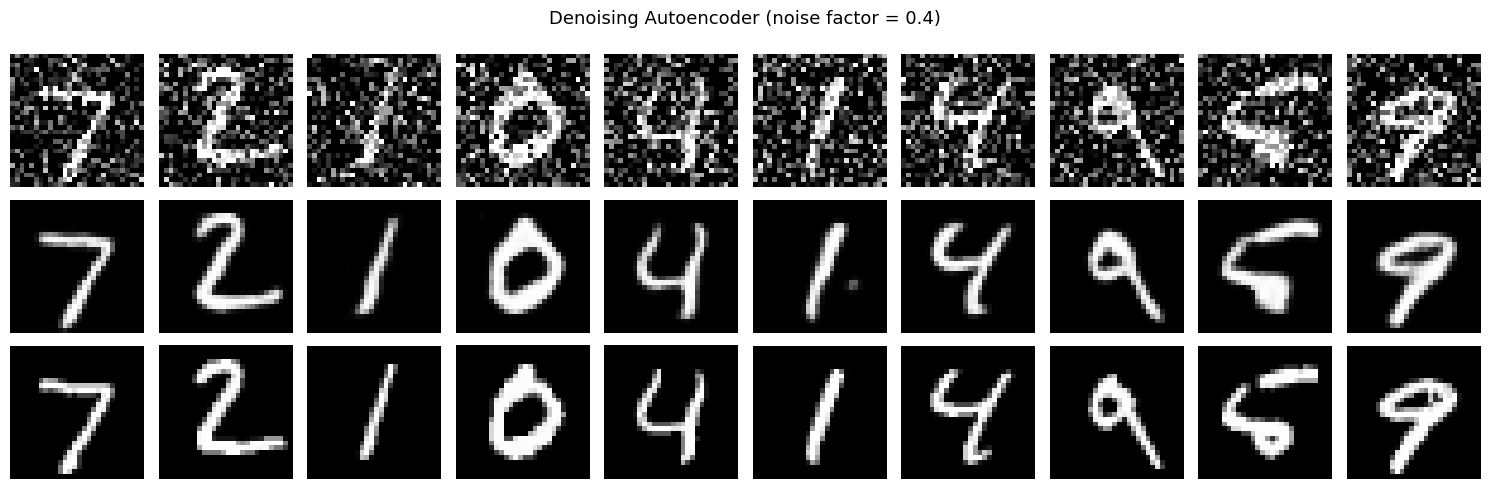

In [6]:
model.eval()
images, _ = next(iter(test_loader))
images = images[:10].to(device)
noisy = add_noise(images)
with torch.no_grad():
    recons = model(noisy)

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i in range(10):
    axes[0, i].imshow(noisy[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[2, i].axis('off')
axes[0, 0].set_ylabel("Noisy", fontsize=11)
axes[1, 0].set_ylabel("Denoised", fontsize=11)
axes[2, 0].set_ylabel("Original", fontsize=11)
plt.suptitle(f"Denoising Autoencoder (noise factor = {NOISE_FACTOR})", fontsize=13)
plt.tight_layout()
plt.show()